# BookRank Demo

In [1]:
# import dependencies
import igraph as ig
import sqlite3
import bookrank
import pandas as pd

Make sure you have setup the database and graph in [data.ipynb](./data.ipynb)

In [2]:
g = ig.read("graph.pkl", format="pickle")

In [3]:
conn = sqlite3.connect("data.db")

In order to get book recommendations, we need the specific bookId of the last read book and genreId of the genre that user wants to read next.

In [4]:
# USE THIS CELL TO GET THE bookId OF THE BOOKS

# enter the search query here
searchTerm = "451"

search = rf"%{searchTerm}%"
searchTuple = (search, search,)

query = "SELECT * FROM books WHERE title LIKE ? OR authors LIKE ?"

df = pd.read_sql(query, conn, params=searchTuple)

display(df)

,bookId,goodreadsBookId,isbn,authors,title,averageRating,weightedScore,ratingsCount
0,48,4381,307347974,Ray Bradbury,Fahrenheit 451,3.97,3.092830,570498
1,7711,5199185,080905101X,"Tim Hamilton, Ray Bradbury",Fahrenheit 451: The Authorized Adaptation,3.92,3.000249,11809


In [5]:
dfGenres = pd.read_sql("SELECT * FROM genres", conn)
display(dfGenres)

,genreId,name
0,0,young-adult
1,1,fiction
2,2,fantasy
3,3,science-fiction
4,4,romance
5,5,classics
6,6,paranormal
7,7,historical-fiction
8,8,contemporary
9,9,mystery


In [4]:
br = bookrank.BookRank(g, conn)

In [ ]:
# get book recommendations based on bookId and genreId
# by default, n = 10 and k = 100
# we select 10 random books from top 100 neighbours

df = br.get_book_recco_info(48, genreId=24)
display(df[['bookId', 'title', 'combinedScore', 'nAB', 'authors']])

,bookId,title,combinedScore,nAB,authors
0,209,"The Silence of the Lambs (Hannibal Lecter, #2)",0.011481,2004,Thomas Harris
1,213,The Metamorphosis,0.016954,3356,"Franz Kafka, Stanley Corngold"
2,243,Misery,0.009526,1842,Stephen King
3,349,'Salem's Lot,0.008326,1602,Stephen King
4,367,"Odd Thomas (Odd Thomas, #1)",0.004808,928,Dean Koontz
5,612,"The Drawing of the Three (The Dark Tower, #2)",0.007074,1176,Stephen King
6,651,The Phantom of the Opera,0.004764,924,"Gaston Leroux, Alexander Teixeira de Mattos"
7,665,"The Passage (The Passage, #1)",0.004791,866,Justin Cronin
8,670,The Dead Zone,0.005562,1080,Stephen King
9,865,Night Shift,0.004345,824,"Stephen King, John D. MacDonald"


In [5]:
# you can the books recommended as a list of bookId 
# here we set n = 10 and k = 10, to select exact top 10 book recommendations
df = br.get_book_recco(48, genreId=24, n = 10, k = 10)

print(df)

[213, 168, 97, 72, 84, 173, 95, 104, 71, 13]


Median: 0.022484512007482187


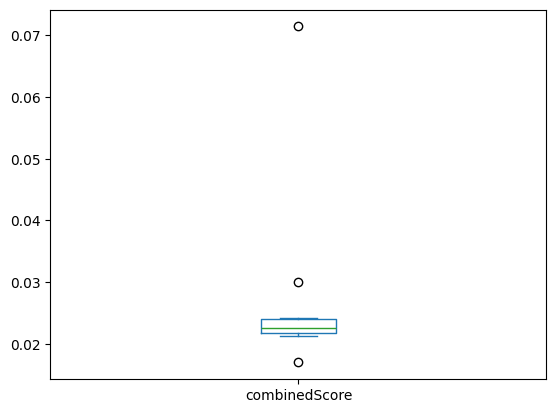

In [14]:
# We get the stats of the combinedScores of the recommendations
df = br.get_book_recco_info(48, genreId=24, n = 10, k = 10 )

df.plot(x="bookId", y="combinedScore", kind="box")
print(f"Median: {df["combinedScore"].median()}")

In [13]:
display(df)

,bookId,goodreadsBookId,isbn,authors,title,averageRating,weightedScore,ratingsCount,bookIdB,nAB,localScore,globalScore,combinedScore
0,139,9460487,1594744769,Ransom Riggs,Miss Peregrine’s Home for Peculiar Children (M...,3.89,2.979543,613674,139,1726,2.804080,2.979543,0.008498
1,173,227463,393312836,Anthony Burgess,A Clockwork Orange,3.98,3.111346,431195,173,4290,3.011126,3.111346,0.022652
2,176,18342,451169514,Stephen King,It,4.18,3.481671,292592,176,2306,3.222251,3.481671,0.013047
3,209,23807,99446782,Thomas Harris,"The Silence of the Lambs (Hannibal Lecter, #2)",4.14,3.407606,351107,209,2004,3.264798,3.407606,0.011481
4,232,43615,452284694,Stephen King,"The Gunslinger (The Dark Tower, #1)",3.99,3.129862,332494,232,2372,3.064072,3.129862,0.012745
5,243,10614,450417395,Stephen King,Misery,4.11,3.352057,334647,243,1842,2.939613,3.352057,0.009526
6,499,28676,679735771,Bret Easton Ellis,American Psycho,3.81,2.924746,166083,499,1330,2.843735,2.924746,0.006636
7,691,10569,743455967,Stephen King,On Writing: A Memoir of the Craft,4.31,3.722381,131481,691,1004,3.720094,3.722381,0.006547
8,1248,59219,375507779,"Stephen King, Peter Straub","The Talisman (The Talisman, #1)",4.12,3.370573,79508,1248,624,3.255203,3.370573,0.003570
9,1354,51497,141439734,"Robert Louis Stevenson, Robert Mighall",The Strange Case of Dr. Jekyll and Mr. Hyde an...,3.94,3.037281,80299,1354,770,2.978387,3.037281,0.004025


We can filter out the books already read before by adding it to reading history.

In [ ]:
# add some books to reading history

# this are the books recommendations from above
readHist = [213, 168, 97, 72, 84, 173, 95, 104, 71, 13]

for i in readHist:
    br.add_book(i)

# now get recommendations
df = br.get_book_recco(48, genreId=24, n = 10, k = 10)

# the recommendations for the top 10 will be different from the ones above
print(df)

[547, 402, 217, 209, 239, 232, 322, 176, 205, 196]


In [7]:
conn.close()